# 02 — Combine daily files into per-sensor Parquet

Each study sensor is matched to its raw data folder by the `SLxxx` code, all daily CSVs are stacked, and the result is written to a single Parquet per sensor in `data/processed/`. A coverage inventory is saved for the incremental loader (`src/loader.py`) to read.

**`FORCE_REBUILD = False`** (set in the next cell) skips sensors that already have a Parquet on disk. After the first run, re-running this notebook is near-instant. For day-to-day data refreshes, use `python -m src.loader` instead.

In [1]:
import sys
import re
import time
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from src.config import *
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set True only when we need to fully rebuild from raw CSVs (slow; touches OneDrive)
FORCE_REBUILD = False

study = pd.read_csv(Tables / "study_sensors.csv")
print(f"Study sensors: {len(study)}")
study.head()

Study sensors: 48


,sensor_id,sensor_name,location_type,lat,lon
0,15,SL001 Sunnyview Terrace,outdoor,53.774956,-1.565842
1,27,SL003 - Corn Exchange Cabinet,outdoor,53.796494,-1.540428
2,26,SL005 Kirkstall Valley Primary,outdoor,53.808520,-1.586729
3,47,SL006 - Primrose Hill Primary,outdoor,53.801888,-1.667109
4,45,SL007 Ninelands Primary,outdoor,53.789272,-1.377445


### Match study sensors to disk folders

`sl_code` extracts a zero-padded three-digit code from any sensor name or folder name (e.g. `SL_017_-_Boston_Spa` → `SL017`), so matches are robust to punctuation differences between the summary CSV and the disk.

A reverse audit also lists folders on disk that fall outside the study set — either registered-but-excluded sensors, or instruments from separate deployments (`Wetherby_Town_WB01/WB02`, `ULeedsSEE_North_Bldg`) that were never registered in `sensor_summary.csv`.

In [2]:
def is_daily(name):
    return re.fullmatch(r"\d{4}-\d{2}-\d{2}\.csv", name) is not None

disk_folders = [
    item.name for item in sorted(DATA_DIR.iterdir())
    if item.is_dir() and any(is_daily(p.name) for p in item.rglob("*.csv"))
]
print(f"Folders on disk with daily data: {len(disk_folders)}")

def sl_code(text):
    m = re.search(r"SL[_ ]?0*(\d+)", str(text).upper())
    return f"SL{int(m.group(1)):03d}" if m else None

study["code"]  = study["sensor_name"].apply(sl_code)
folder_by_code = {sl_code(f): f for f in disk_folders if sl_code(f)}

study["folder"] = study["code"].map(folder_by_code)
matched   = study.dropna(subset=["folder"])
unmatched = study[study["folder"].isna()]

print(f"Matched to a folder: {len(matched)}")
print(f"Not matched (no folder found): {len(unmatched)}")
if len(unmatched):
    print(unmatched[["sensor_name", "code"]].to_string(index=False))

# Reverse audit: folders on disk not in the study set
study_folders    = set(matched["folder"])
excluded_folders = [f for f in disk_folders if f not in study_folders]
all_codes        = set(study["code"].dropna())
print(f"\nFolders on disk outside the study set: {len(excluded_folders)}")
for f in sorted(excluded_folders):
    tag = "(registered-excluded)" if sl_code(f) and sl_code(f) in all_codes else "(not registered)"
    print(f"  {f}  {tag}")

Folders on disk with daily data: 72
Matched to a folder: 47
Not matched (no folder found): 1
    sensor_name  code
SL71 - Kentmere SL071

Folders on disk outside the study set: 25
  SEE_2  (not registered)
  SL002  (not registered)
  SL004  (not registered)
  SL010_Wetherby_Racecourse  (not registered)
  SL013_Knowsthorpe_Gate  (not registered)
  SL014_Pudsey  (not registered)
  SL039  (not registered)
  SL043  (not registered)
  SL046  (not registered)
  SL047  (not registered)
  SL048  (not registered)
  SL049  (not registered)
  SL052  (not registered)
  SL053  (not registered)
  SL058  (not registered)
  SL059  (not registered)
  SL061  (not registered)
  SL063  (not registered)
  SL064  (not registered)
  SL065  (not registered)
  SL066  (not registered)
  SL067  (not registered)
  ULeedsSEE_North_Bldg  (not registered)
  Wetherby_Town_WB01  (not registered)
  Wetherby_Town_WB02  (not registered)


### Combine function

All daily CSVs for one sensor are stacked, timestamps parsed (ISO 8601), and the result sorted chronologically. Per-sensor stats are returned alongside the data.

In [3]:
def combine_one_sensor(folder_name):
    """Stack all daily CSVs for one sensor. Returns (dataframe, stats dict)."""
    folder = DATA_DIR / folder_name
    files  = sorted(p for p in folder.rglob("*.csv") if is_daily(p.name))

    frames, empty_days, bad_files = [], 0, 0
    for f in files:
        try:
            d = pd.read_csv(f)
            if len(d) == 0:
                empty_days += 1
            else:
                frames.append(d)
        except Exception:
            bad_files += 1

    if not frames:
        return pd.DataFrame(), {
            "folder": folder_name, "rows": 0, "days_with_data": 0,
            "empty_days": empty_days, "bad_files": bad_files,
            "start": None, "end": None,
        }

    df = pd.concat(frames, ignore_index=True)
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], format="ISO8601", errors="coerce")
    df = df.sort_values(DATE_COL).reset_index(drop=True)
    df.insert(0, "sensor", folder_name)

    return df, {
        "folder": folder_name, "rows": len(df),
        "days_with_data": df[DATE_COL].dt.date.nunique(),
        "empty_days": empty_days, "bad_files": bad_files,
        "start": df[DATE_COL].min(), "end": df[DATE_COL].max(),
    }

### Run the combine

With `FORCE_REBUILD = False`, sensors with an existing Parquet are skipped and their stats are read directly from the Parquet header. Only sensors with no Parquet on disk touch OneDrive. Set `FORCE_REBUILD = True` to rebuild everything from raw CSVs (slow — only needed if the raw data has been corrected).

In [4]:
inventory = []
t0 = time.time()
folders_to_do = matched["folder"].tolist()

for i, fname in enumerate(folders_to_do, 1):
    out_path = PROCESSED / f"{fname}.parquet"

    if not FORCE_REBUILD and out_path.exists():
        # Already built — read just the date column to get stats, avoid re-reading CSVs
        df_ex = pd.read_parquet(out_path, columns=[DATE_COL])
        stats = {
            "folder": fname, "rows": len(df_ex),
            "days_with_data": df_ex[DATE_COL].dt.date.nunique(),
            "empty_days": 0, "bad_files": 0,
            "start": df_ex[DATE_COL].min(), "end": df_ex[DATE_COL].max(),
        }
        inventory.append(stats)
        print(f"[{i}/{len(folders_to_do)}] {fname}  cached ({stats['rows']:,} rows)")
        continue

    print(f"[{i}/{len(folders_to_do)}] {fname} ...", end=" ")
    df, stats = combine_one_sensor(fname)
    if df.empty:
        print("no data")
    else:
        df.to_parquet(out_path, index=False)
        print(f"{stats['rows']:,} rows  ({stats['days_with_data']} days, {stats['empty_days']} empty)")
    inventory.append(stats)

print(f"\nDone in {time.time()-t0:.0f}s")

[1/47] SL001_Sunnyview_Terrace  cached (1,038,078 rows)
[2/47] SL003_Corn_Exchange_Cabinet  cached (575,937 rows)
[3/47] SL005_Kirkstall_Valley_Primary  cached (523,797 rows)
[4/47] SL006  cached (1,061,408 rows)
[5/47] SL007_Ninelands_Primary  cached (1,050,952 rows)
[6/47] SL008_Westgate_Primary  cached (771,480 rows)
[7/47] SL009  cached (168,047 rows)
[8/47] SL011  cached (832,643 rows)
[9/47] SL012_Morley  cached (934,514 rows)
[10/47] SL015_-_Garforth_Main_Street  cached (417,638 rows)
[11/47] SL016_Scholes_Main_Street  cached (735,046 rows)
[12/47] SL_017_-_Boston_Spa_Town_Centre  cached (470,881 rows)
[13/47] SL018_East_Ardsley_A650  cached (632,321 rows)
[14/47] SL019_Cornwall_Crescent_Rothwell  cached (735,371 rows)
[15/47] SL020  cached (635,026 rows)
[16/47] SL021_Kippax_Church_Lane  cached (591,317 rows)
[17/47] SL022_Church_Lane_Horsforth  cached (507,381 rows)
[18/47] SL023_Nelson_Street_Otley  cached (276,084 rows)
[19/47] SL024_Wetherby_Town_Centre  cached (1,017,322 r

### Inventory table

Coverage is reported against two different denominators, because they answer
different questions and are easy to confuse. `active_coverage_pct` is the share
of days **within a sensor's own operational span** that carry data — how
reliably the unit reported while it was deployed. `study_coverage_pct` is the
share of the **whole study period** — how much of the four years the sensor
contributes. A unit that ran perfectly for six months scores highly on the
first and poorly on the second, and only the second says how much it adds to a
network-level statistic.

`sensor_inventory.csv` is also the authoritative folder list that
`src/loader.py` reads for incremental updates.

In [5]:
inv = pd.DataFrame(inventory)
inv = inv.merge(matched[["folder", "sensor_name", "lat", "lon"]], on="folder", how="left")

inv["span_days"] = (pd.to_datetime(inv["end"]) - pd.to_datetime(inv["start"])).dt.days + 1

# Two denominators, kept apart on purpose (see the note above).
study_start = pd.to_datetime(inv["start"]).min()
study_end   = pd.to_datetime(inv["end"]).max()
study_days  = (study_end - study_start).days + 1

inv["active_coverage_pct"] = (inv["days_with_data"] / inv["span_days"] * 100).round(1)
inv["study_coverage_pct"]  = (inv["days_with_data"] / study_days * 100).round(1)

print(f"study period: {study_start.date()} to {study_end.date()}  ({study_days} days)")
print(f"median coverage: {inv['active_coverage_pct'].median():.0f}% of own span, "
      f"{inv['study_coverage_pct'].median():.0f}% of the study period")

cols = ["sensor_name", "folder", "rows", "days_with_data", "empty_days",
        "span_days", "active_coverage_pct", "study_coverage_pct",
        "start", "end", "bad_files"]
inv = inv[cols].sort_values("sensor_name")
inv.to_csv(Tables / "sensor_inventory.csv", index=False)
print("Saved -> outputs/tables/sensor_inventory.csv")
inv

study period: 2022-03-07 to 2026-08-10  (1618 days)
median coverage: 66% of own span, 58% of the study period
Saved -> outputs/tables/sensor_inventory.csv


,sensor_name,folder,rows,days_with_data,empty_days,span_days,active_coverage_pct,study_coverage_pct,start,end,bad_files
0,SL001 Sunnyview Terrace,SL001_Sunnyview_Terrace,1038078,1445,0,1446,99.9,89.3,2022-03-07 18:37:08+00:00,2026-02-19 18:57:20+00:00,0
1,SL003 - Corn Exchange Cabinet,SL003_Corn_Exchange_Cabinet,575937,829,0,1081,76.7,51.2,2022-03-09 14:45:42+00:00,2025-02-22 00:01:37+00:00,0
2,SL005 Kirkstall Valley Primary,SL005_Kirkstall_Valley_Primary,523797,762,0,1313,58.0,47.1,2022-07-05 08:58:00+00:00,2026-02-06 11:27:41+00:00,0
3,SL006 - Primrose Hill Primary,SL006,1061408,1491,0,1616,92.3,92.2,2022-03-09 15:09:03+00:00,2026-08-10 23:58:23+00:00,0
4,SL007 Ninelands Primary,SL007_Ninelands_Primary,1050952,1484,0,1616,91.8,91.7,2022-03-09 15:15:38+00:00,2026-08-10 23:59:22+00:00,0
5,SL008 Westgate Primary,SL008_Westgate_Primary,771480,1110,0,1580,70.3,68.6,2022-03-09 15:26:26+00:00,2026-07-06 12:12:52+00:00,0
6,SL009 - Roundhay Golf Club,SL009,168047,254,0,834,30.5,15.7,2022-03-09 15:33:26+00:00,2024-06-20 09:27:33+00:00,0
7,"SL011 - West End Grove, Horsforth",SL011,832643,1473,0,1616,91.2,91.0,2022-03-09 15:47:23+00:00,2026-08-10 23:58:38+00:00,0
8,"SL012 - Fountain Street, Morley",SL012_Morley,934514,1304,0,1496,87.2,80.6,2022-03-09 15:51:22+00:00,2026-04-13 05:45:31+00:00,0
9,SL015 - Garforth Main Street,SL015_-_Garforth_Main_Street,417638,590,0,809,72.9,36.5,2022-03-22 15:59:02+00:00,2024-06-08 00:34:40+00:00,0


### Data availability by sensor

Each bar spans a sensor's first to last recorded reading. Sensors with short bars or early end dates are candidates for closer inspection in NB03.

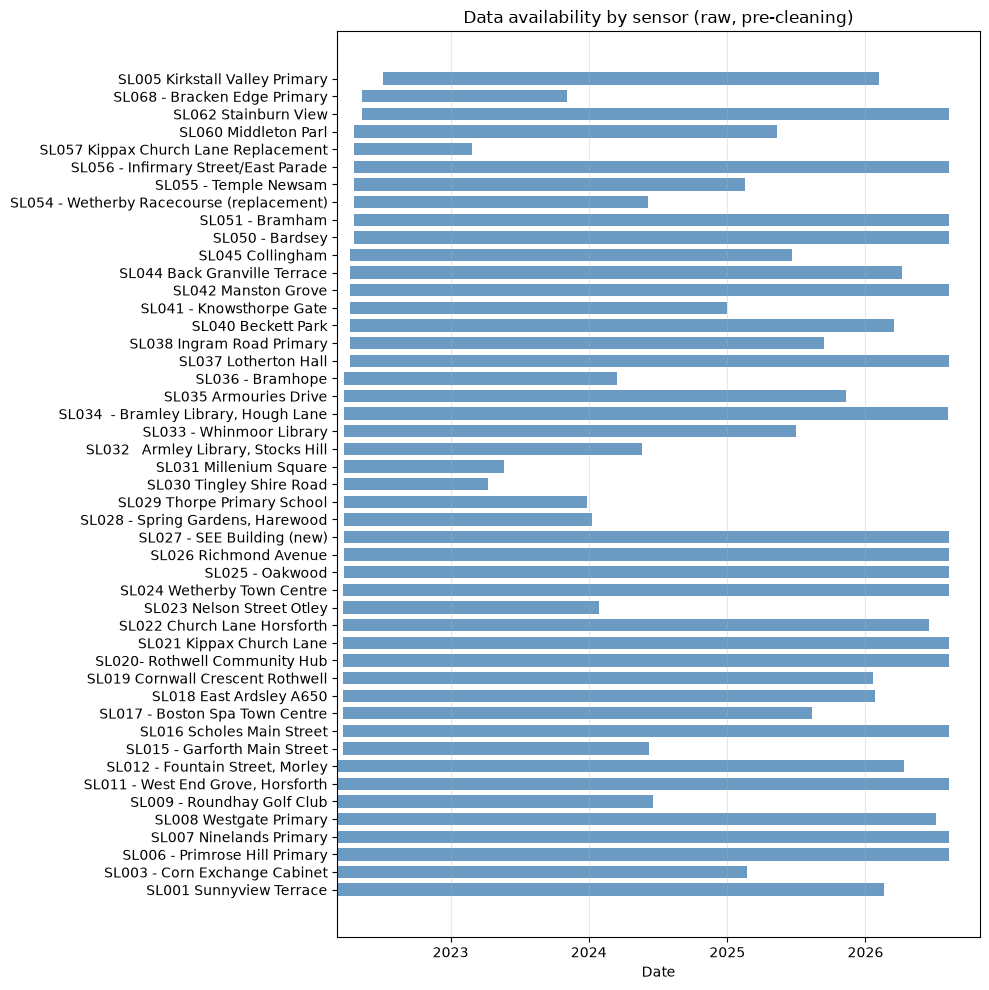

In [6]:
plot_inv = inv.dropna(subset=["start", "end"]).copy()
plot_inv["start"] = pd.to_datetime(plot_inv["start"])
plot_inv["end"]   = pd.to_datetime(plot_inv["end"])
plot_inv = plot_inv.sort_values("start")

fig, ax = plt.subplots(figsize=(10, 10))

for row in plot_inv.itertuples():
    ax.barh(row.sensor_name, (row.end - row.start).days,
            left=row.start, height=0.7, color="steelblue", alpha=0.8)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("Date")
ax.set_title("Data availability by sensor (raw, pre-cleaning)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(Figures / "02_sensor_coverage.png", dpi=150, bbox_inches="tight")
plt.show()